# N-gram 언어 모델

**N-gram 언어 모델** 은 연속한 `N`개 토큰의 출현 빈도로 다음 토큰의 조건부확률을 추정하는 통계적 언어 모델이다. 전체 과거를 모두 기억하는 대신 현재 토큰 바로 앞의 `N-1`개 토큰만 문맥으로 사용한다.
(* 단어를 하나씩 학습하는 것이 아니라 앞뒤로 묶어서 학습하는 것. )

## N에 따른 문맥 범위

`N`이 커지면 더 구체적인 순서를 조건으로 사용할 수 있지만, 동시에 세어야 할 토큰 조합도 빠르게 늘어난다.

- **Bigram (`N=2`)**: 직전 토큰 하나로 현재 토큰을 예측한다.
- **Trigram (`N=3`)**: 직전 토큰 두 개로 현재 토큰을 예측한다.

```text
Bigram 가정: P(현재 토큰 | 전체 과거 토큰) ≈ P(현재 토큰 | 직전 토큰)
```

## 빈도로 학습하는 방식

N-gram에서는 별도의 신경망이나 역전파 없이 코퍼스의 토큰 조합을 세는 과정 자체가 학습이다. 특정 문맥 뒤에 각 후보가 나온 횟수를 같은 문맥의 전체 횟수로 나누어 조건부확률을 만든다.

## 장점과 한계

빈도표의 분자와 분모를 직접 확인할 수 있어 구현이 단순하고 결과를 설명하기 쉽다. 그러나 학습에서 보지 못한 N-gram은 확률이 `0`이 되는 희소성 문제가 있으며, `N`을 키우면 가능한 조합이 급격히 늘고 `N-1`보다 먼 장기 문맥은 반영하지 못한다.

## 대표 사용처

계산이 빠르고 확률 근거를 추적할 수 있어 소규모 기준 모델과 후보 점수 계산에 유용하다.

- 입력 자동완성과 다음 단어 후보 제안
- 음성 인식·철자 교정에서 여러 후보의 언어적 자연스러움 비교
- 신경망 언어 모델과 비교할 빈도 기반 baseline

## 이번 노트북에서 확인할 내용

한국어 미니 코퍼스에 `<s>`, `</s>`, `<OOV>`를 추가하고 다음 흐름을 직접 계산한다.

- Bigram 빈도와 조건부확률
- Add-k smoothing이 미관찰 전이에 확률을 배분하는 과정
- 학습·held-out·OOV 문장의 perplexity 비교
- 관찰 빈도를 가중치로 사용하는 다음 토큰 sampling 생성

먼저 문장 경계와 OOV를 하나의 토큰으로 표현한 뒤, 같은 토큰 시퀀스를 빈도 계산·평가·생성에서 일관되게 사용한다.


## 01. 학습 코퍼스와 특수 토큰

문장 시작과 끝도 확률 모델이 예측할 사건이므로 경계와 미등록 단어를 일반 단어처럼 토큰으로 표현한다.

- `<s>`: 첫 단어를 예측할 때 사용할 시작 문맥이다.
- `</s>`: 문장이 끝날 확률을 학습하고 생성 종료를 판단하는 다음 토큰 후보이다.
- `<OOV>`: 학습 어휘에 없는 문자열을 하나의 알려진 토큰으로 치환한다.

실제 모델에서는 낮은 빈도의 단어를 `<OOV>`로 바꾸어 학습 중에도 이 토큰의 문맥을 관찰하게 한다. 이 작은 실습은 모든 학습 단어를 어휘에 보존하므로 `<OOV>`는 held-out 문장의 미등록 단어를 표시하는 데 사용한다. 이어지는 코드에서는 모든 문장에 같은 경계·OOV 정책을 적용하고, 첫 시퀀스가 `['<s>', ..., '</s>']` 형태인지 확인한다.


In [1]:
from collections import Counter
import math
import random

train_sentences = [
    "나는 자연어 처리를 공부한다",
    "나는 자연어 처리를 배운다",
    "학생은 자연어 처리를 공부한다",
    "학생은 언어 모델을 공부한다",
    "나는 언어 모델을 공부한다",
    "언어 모델은 다음 단어를 예측한다",
    "자연어 처리는 문장을 분석한다",
    "머신러닝 모델은 데이터를 학습한다",
    "학생은 머신러닝 모델을 배운다",
    "나는 다음 단어를 예측한다",
]

START_TOKEN = "<s>"
END_TOKEN = "</s>"
OOV_TOKEN = "<OOV>"

# "나는 자연어 처리를 공부한다"  -->  "나는 / 자연어 / 처리를 / 공부한다" 이런 식으로 쪼갬.
train_tokenized = [sentence.split() for sentence in train_sentences]

# 어휘 사전 생성
# Set: {V1, V2, V3} 형태의 컬렉션(자료 구조 모음), 자동 중복 제거
# -> 중복 없는 어휘 사전 생성
vocabulary = {
    token
    for sentence_tokens in train_tokenized
    for token in sentence_tokens
}

# 어휘 사전에 <START_TOKEN>, <END_TOKEN>, <OOV_TOKEN> 추가 ==  <s>, </s>, <OOV>
vocabulary.update({START_TOKEN, END_TOKEN, OOV_TOKEN})

def add_boundaries(tokens):
    """학습 어휘 밖의 토큰을 <OOV>로 바꾸고 문장 경계를 추가한다."""
    normalized = []

    for token in tokens:
        normalized_token = token if token in vocabulary else OOV_TOKEN
        normalized.append(normalized_token)

    return [START_TOKEN, *normalized, END_TOKEN]

train_sequences = [
    add_boundaries(sentence_tokens)
    for sentence_tokens in train_tokenized
]

print("학습 문장 수:", len(train_sequences))
print("어휘 크기:", len(vocabulary))
print("경계 추가 예시:", train_sequences[0])


학습 문장 수: 10
어휘 크기: 21
경계 추가 예시: ['<s>', '나는', '자연어', '처리를', '공부한다', '</s>']


## 02. Bigram 빈도와 조건부확률 학습

`P(다음 토큰 | 이전 토큰)`은 특정 이전 토큰 뒤에 다음 토큰이 나온 횟수를 이전 토큰이 문맥으로 사용된 전체 횟수로 나누어 계산한다. 문자열 시퀀스는 다음 세 단계로 빈도 기반 모델이 된다.

- 인접한 `(이전 토큰, 다음 토큰)` 쌍을 만들어 Bigram별 횟수를 센다.
- 같은 이전 토큰에서 출발한 모든 횟수를 합해 문맥 빈도를 만든다.
- Bigram 빈도를 문맥 빈도로 나누어 다음 토큰 조건부확률을 계산한다.

```text
P(자연어 | 나는)
= count(나는, 자연어) / count(나는, *)
```

여기서 `count(나는, *)`는 `나는` 뒤에서 관찰한 모든 다음 토큰 횟수의 합이다. 같은 코퍼스를 다시 학습하면 같은 빈도와 확률을 얻으며, 새로운 문장을 추가하면 횟수와 확률이 달라진다. 코드 출력에서는 `나는` 뒤의 후보별 빈도와 확률 합이 `1`이 되는지, 미관찰 Bigram의 확률이 `0`인지 확인한다.


In [2]:
# 인접 토큰 쌍과 문맥 빈도를 세어 Bigram 조건부확률을 계산한다.
bigram_counts = Counter()

# (이전 단어, 다음 단어)의 빈도수 측정
for sequence in train_sequences:
    for previous_token, next_token in zip(sequence, sequence[1:]):
        bigram_counts[(previous_token, next_token)] += 1

context_counts = Counter()

# (이전 토큰, *) : 이전 단어가 문맥 전체에서 몇 번 나왔는지 카운트 -> 확률 계산 시 분모로 사용
for (previous_token, _), count in bigram_counts.items():
    context_counts[previous_token] += count

# 특정 이전 단어 이후 다음 단어가 나올 확률을 반환하는 함수
def bigram_probability(previous_token, next_token):
    """관찰한 Bigram의 최대우도 조건부확률을 반환한다."""
    denominator = context_counts[previous_token] # 분모

    # 학습되지 않은 단어로 이루어진 문장이 들어왔을 때
    if denominator == 0:
        return 0.0

    return bigram_counts[(previous_token, next_token)] / denominator

# 중첩 generator 대신 단계를 나누어 "나는" 뒤의 실제 후보, 빈도, 확률 흐름을 출력하는 부분
observed_after_i = []
for (previous_token, next_token), count in bigram_counts.items():
    if previous_token == "나는":
        probability = bigram_probability(previous_token, next_token)
        observed_after_i.append((next_token, count, probability))

observed_after_i.sort(key=lambda item: (-item[1], item[0]))

print("'나는' 뒤의 학습 결과:")
for next_token, count, probability in observed_after_i:
    print(f"  {next_token:<8} 빈도={count}  확률={probability:.3f}")

print()
print("관찰하지 않은 P(문장을 | 나는):", bigram_probability("나는", "문장을"))


'나는' 뒤의 학습 결과:
  자연어      빈도=2  확률=0.500
  다음       빈도=1  확률=0.250
  언어       빈도=1  확률=0.250

관찰하지 않은 P(문장을 | 나는): 0.0


## 03. 관찰하지 못한 관계와 Add-k Smoothing

- 학습 문장: 학습 중 본 문장
- held-out 문장: 단어는 알지만 일부 Bigram을 처음 보는 문장
- OOV 문장: 학습 어휘에 없는 단어가 `<OOV>`로 바뀌는 문장

held-out 문장에 학습 중 한 번도 보지 못한 Bigram이 하나라도 있으면 문장 전체 확률은 `0`이 된다.

**Smoothing(평활화)** 은 관찰하지 못한 관계에도 작은 확률을 배분하여 이 문제를 완화한다. (*평평함(flatten)과 다름. 굴곡(웨이브)은 있어도 뾰족함은 없는 상태)

Add-k smoothing은 모든 다음 토큰 후보의 빈도에 작은 `k`를 더한다. 분자만 늘리면 확률의 합이 `1`을 넘으므로 분모에도 `k × 다음 토큰 후보 수`를 더한다. 따라서 관찰 후보와 미관찰 후보를 포함한 전체 분포가 다시 합 `1`로 정규화된다.

```text
P_add-k(w_i | w_(i-1))
= (count(w_(i-1), w_i) + k)
  / (count(w_(i-1), *) + k × |V_next|)
```

Smoothing은 관찰하지 않은 표현을 정확히 이해하게 만드는 기술로 볼 수 없다. 확률 `0`을 피하고 학습 데이터 밖의 문장을 비교할 수 있게 하는 보정이다. 이어지는 코드는 같은 미관찰 쌍의 smoothing 전후 확률과 전체 후보 확률 합을 함께 출력하며, 이 유한 확률이 다음 perplexity 계산의 입력이 된다.


In [3]:
# 다음 토큰 예측 어휘 사전
# - <s> 토큰 제거 -> 시작 토큰은 무조건 이전 토큰이다!!!
prediction_vocabulary = sorted(vocabulary - {START_TOKEN})

# k=0.1 --> 확률이 0이 되는 경우 더할 값
def smoothed_bigram_probability(previous_token, next_token, k=0.1):
    """Add-k smoothing을 적용한 Bigram 조건부확률을 반환한다."""
    # 모든 후보의 빈도에 k를 더하므로 미관찰 전이도 분자 k를 가져 0보다 커진다.
    numerator = bigram_counts[(previous_token, next_token)] + k

    # 후보 20개에 각각 k를 더한 전체 양만큼 분모도 k * |V_next|로 보정해야 확률 합이 1이 된다.
    denominator = context_counts[previous_token] + k * len(prediction_vocabulary)
    # 정규화된 값은 전체 후보 합 검증과 문장별 smoothed perplexity의 전이 확률로 이어진다.
    return numerator / denominator


# 이 쌍은 앞 셀에서 빈도 0이었던 동일한 사례이므로 smoothing 전후를 직접 비교할 수 있다.
unseen_pair = ("나는", "문장을")

# *unseen_pair는 튜플의 두 문자열을 함수의 previous_token과 next_token 인자로 펼친다.
print(
    "smoothing 전:",
    bigram_probability(*unseen_pair),
)
print(
    "smoothing 후:",
    round(smoothed_bigram_probability(*unseen_pair, k=0.1), 6),
)

# 각 후보의 평활 확률을 먼저 모은 뒤 합을 검사한다.
# 이 목록은 수식 검증용 중간 결과이며 다음 perplexity 셀은 함수를 직접 다시 호출한다.
candidate_probabilities = [
    smoothed_bigram_probability("나는", candidate, k=0.1)
    for candidate in prediction_vocabulary
]
probability_sum = sum(candidate_probabilities)
print("'나는' 뒤 전체 후보 확률 합:", round(probability_sum, 6))

smoothing 전: 0.0
smoothing 후: 0.016667
'나는' 뒤 전체 후보 확률 합: 1.0


## 04. Perplexity로 문장 예측 난이도 비교

**Perplexity(PPL)** 는 정답 토큰들에 부여한 확률의 기하평균에 역수를 취한 평가값이다. 같은 tokenizer·어휘·평가 조건에서는 낮을수록 모델이 실제 다음 토큰에 더 높은 확률을 부여했다는 뜻이다.

문장 확률을 직접 계속 곱하면 매우 작은 값이 되어 계산이 불안정해질 수 있으므로 로그확률을 더한 뒤 평균을 사용한다. 이 코드에서 `T`는 `<s>` 다음의 첫 토큰부터 `</s>`까지 예측한 Bigram 전이 수이다.

```text
PPL = exp(-(1 / T) × Σ log P(다음 토큰 | 이전 토큰))
```

계산 코드는 각 Bigram의 확률을 로그로 더하고, 전이 수로 평균을 낸 뒤 `exp()`로 원래 척도에 되돌린다. PPL을 `3`으로 얻었다면 모델이 매 위치에서 평균적으로 약 세 개의 후보 사이에서 헷갈린다고 직관적으로 읽을 수 있다. 다만 이는 동일한 tokenizer·어휘·평가 조건 안에서만 유효하므로 서로 다른 조건의 PPL을 숫자만으로 단순 비교하면 안 된다.

이 실습은 다음 세 문장을 비교한다.

출력에서는 smoothing 전 무한대가 유한값으로 바뀌는지와 세 문장의 상대적 PPL 순서를 함께 본다. smoothing 후에도 OOV 문장의 값이 가장 크다면 이 코퍼스가 해당 OOV 문맥을 충분히 학습하지 못했다는 뜻이다.


In [5]:
# 문장별 로그확률의 음의 평균을 지수화해 perplexity를 계산한다.
def sentence_perplexity(sentence, use_smoothing):
    """문장의 Bigram 확률로 perplexity를 계산한다."""
    sequence = add_boundaries(sentence.split())
    log_probability_sum = 0.0
    predicted_token_count = 0

    for previous_token, next_token in zip(sequence, sequence[1:]):
        if use_smoothing:
            probability = smoothed_bigram_probability(
                previous_token,
                next_token,
                k=0.1,
            )
        else:
            probability = bigram_probability(previous_token, next_token)

        if probability == 0.0:
            return math.inf

        log_probability_sum += math.log(probability)

        predicted_token_count += 1

    average_negative_log_probability = -log_probability_sum / predicted_token_count
    return math.exp(average_negative_log_probability)

evaluation_sentences = {
    "학습 문장": "나는 자연어 처리를 공부한다",
    "held-out 문장": "나는 자연어 처리를 예측한다",
    "OOV 문장": "연구자는 자연어 모델을 평가한다",
}

for label, sentence in evaluation_sentences.items():
    raw_ppl = sentence_perplexity(sentence, use_smoothing=False)
    smoothed_ppl = sentence_perplexity(sentence, use_smoothing=True)

    raw_text = "∞" if math.isinf(raw_ppl) else f"{raw_ppl:.3f}"

    normalized_tokens = add_boundaries(sentence.split())
    print(f"[{label}] {sentence}")
    print("  모델 입력:", normalized_tokens)
    print(f"  smoothing 전 PPL={raw_text}")
    print(f"  smoothing 후 PPL={smoothed_ppl:.3f}")


[학습 문장] 나는 자연어 처리를 공부한다
  모델 입력: ['<s>', '나는', '자연어', '처리를', '공부한다', '</s>']
  smoothing 전 PPL=1.585
  smoothing 후 PPL=2.240
[held-out 문장] 나는 자연어 처리를 예측한다
  모델 입력: ['<s>', '나는', '자연어', '처리를', '예측한다', '</s>']
  smoothing 전 PPL=∞
  smoothing 후 PPL=4.341
[OOV 문장] 연구자는 자연어 모델을 평가한다
  모델 입력: ['<s>', '<OOV>', '자연어', '모델을', '<OOV>', '</s>']
  smoothing 전 PPL=∞
  smoothing 후 PPL=42.823


## 05. 학습한 빈도로 문장 생성

현재 토큰 뒤에서 관찰한 빈도는 다음 토큰 확률뿐 아니라 생성의 sampling 가중치로도 사용할 수 있다. 생성 함수는 다음 순서를 반복한다.

- 현재 토큰을 이전 문맥으로 가진 관찰 Bigram 후보를 모은다.
- 후보 문자열과 빈도를 같은 순서의 목록으로 분리한다.
- 빈도의 상대적 크기를 가중치로 다음 토큰 하나를 뽑는다.
- 선택한 토큰을 새 문맥으로 사용하고 `</s>` 또는 `max_tokens`에서 종료한다.

이 생성은 문법과 의미를 따로 학습한 결과로 볼 수 없다. 작은 코퍼스의 인접 관계를 이어 붙인 결과이므로 자연스러움보다 `빈도 → 선택 → 문맥 갱신` 흐름에 주목한다. seed별 결과가 달라도 모든 인접 쌍이 실제 빈도표에 존재하는지 확인하는 것이 해석 기준이다.


In [ ]:
# 확률분포에서 다음 토큰을 뽑고 새 문맥으로 반복한다.
def generate_bigram_sentence(max_tokens=12, seed=7):
    """관찰한 Bigram 빈도로 다음 토큰을 뽑아 한 문장을 생성한다."""
    random_generator = random.Random(seed)

    current_token = START_TOKEN
    generated_tokens = []

    for _ in range(max_tokens):
        candidates = [
            (next_token, count)
            for (previous_token, next_token), count in bigram_counts.items()
            if previous_token == current_token
        ]

        if not candidates:
            break

        next_tokens = [token for token, _ in candidates]
        weights = [count for _, count in candidates]

        next_token = random_generator.choices(
            next_tokens,
            weights=weights,
            k=1,
        )[0]

        if next_token == END_TOKEN:
            break

        generated_tokens.append(next_token)
        current_token = next_token

    return " ".join(generated_tokens)

for seed in (3, 7, 11):
    print(f"seed={seed:>2}:", generate_bigram_sentence(seed=seed))


## 06. 정리

N-gram에서는 빈도표 자체가 학습된 모델이다. 확률의 근거를 직접 확인할 수 있고 학습 비용이 작지만, 학습 데이터에서 보지 못한 표현과 긴 문맥에 약하다.

Perplexity는 “문장이 좋은가”를 단독으로 판정하는 점수가 아니라 실제 다음 토큰에 모델이 얼마나 높은 확률을 주었는지 나타낸다. smoothing은 무한대 평가를 피하지만 데이터 부족 자체를 해결하지는 않는다.

이 한계를 다음 NNLM은 토큰을 임베딩 벡터로 바꾸고 신경망 가중치를 학습하는 방식으로 다룬다. 정확히 같은 Bigram을 보지 않았더라도 학습된 벡터와 은닉층을 통해 패턴을 공유할 수 있지만, 계산 과정이 빈도표보다 복잡해진다. 다음 노트북에서는 빈도표 대신 어떤 값이 모델의 학습 결과로 남는지 추적한다.

### 빈도·평활화·Perplexity 연결하기

아래 그림은 `나는` 뒤의 Bigram 빈도를 조건부확률로 바꾸고, Add-k로 미관찰 후보에 확률을 배분한 뒤, `exp(-mean(log P))`로 perplexity를 계산하는 흐름을 연결한다. 평활화는 확률 0과 무한대 perplexity를 피하게 하지만, 데이터에 없던 언어적 의미를 새로 만들지는 않는다.

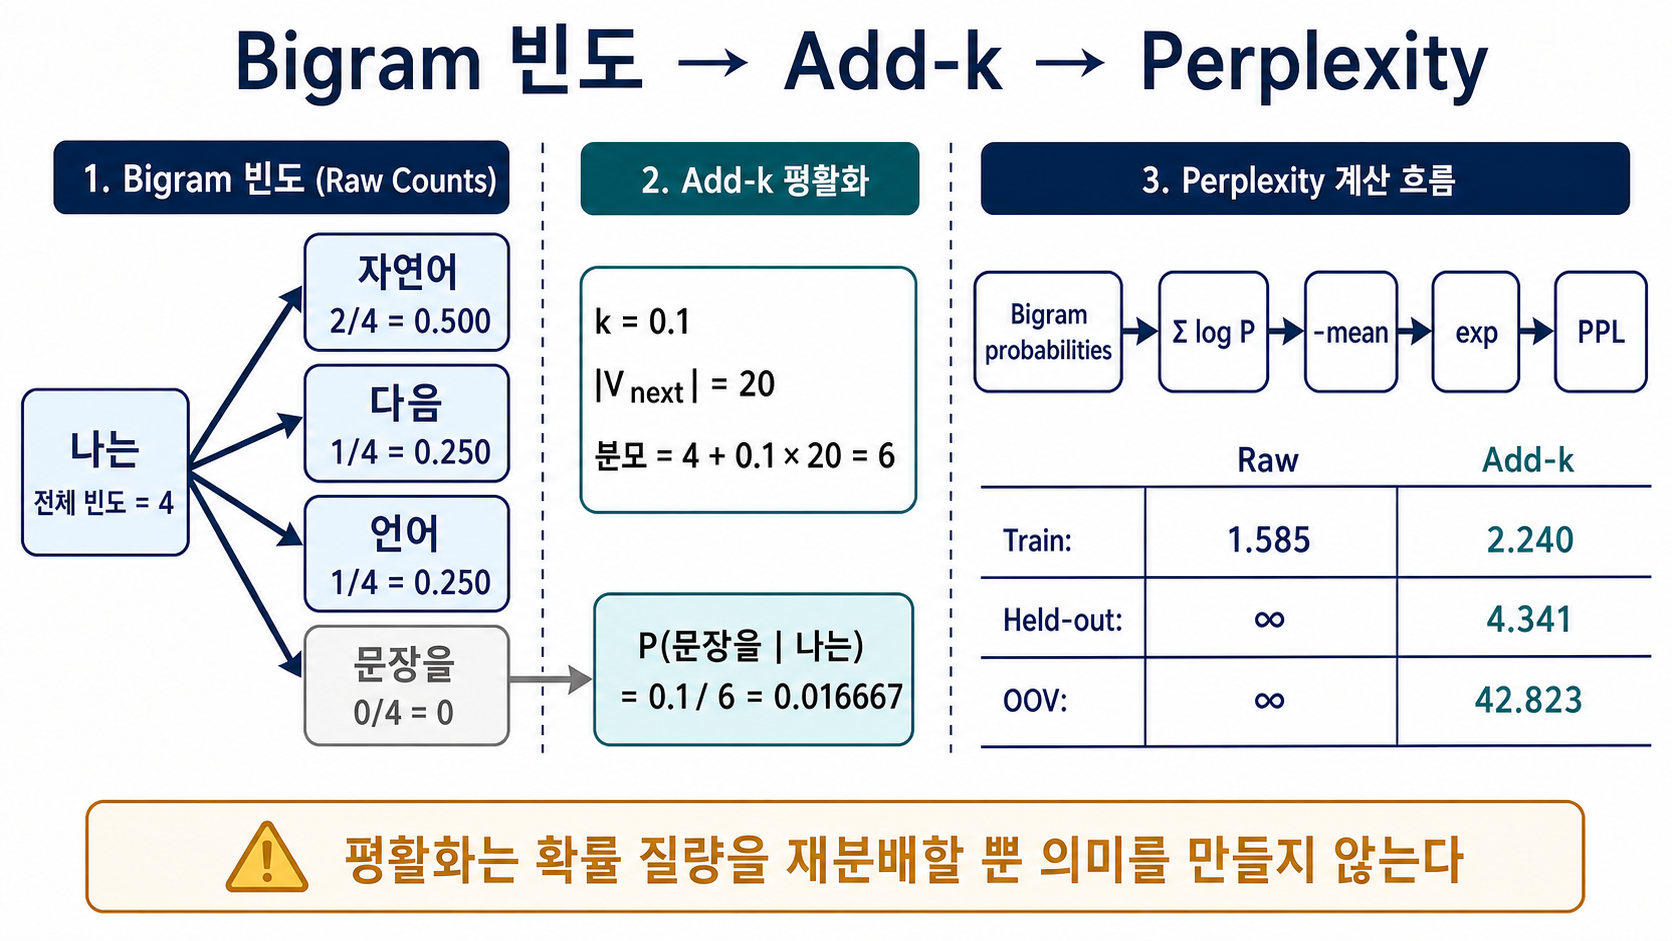
